In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy import constants as const, units as u
import copy

import pyFLD as fld
from scipy.interpolate import interp1d

In [2]:
# Finally, include multiple dust species with their own opacities

d2g = 1e-2 # total dust-to-gas ratio
wl = fld.tools.parse_optool_file('opacities/dustkappa_0.1um.inp')[0]

In [3]:
# === grid and star ===
star = fld.star.Star(M=1*u.M_sun, L=1*u.L_sun, T=5772*u.K, wl=wl)
ri   = fld.grid.get_domain_with_ghosts(0.1, 10, Nx=256, log=True) * u.au
thi  = fld.grid.get_domain_with_ghosts(np.pi/2-0.25, np.pi/2, Nx=512)
phii = fld.grid.get_domain_with_ghosts(0, 2*np.pi, Nx=1)
grid = fld.grid.Grid(ri, thi, phii, geometry='spherical')

# === initialization of objects ===
kwargs = dict(grid=grid, star=star, debug=False)
Gas = fld.fluids.Gas(**kwargs, irradiation='gray', name='basic')

wl, kabs01um, ksca01um, g_asy01um = fld.tools.parse_optool_file('opacities/dustkappa_0.1um.inp')
wl, kabs1um, ksca1um, g_asy1um = fld.tools.parse_optool_file('opacities/dustkappa_1um.inp')
wl, kabs1mm, ksca1mm, g_asy1mm = fld.tools.parse_optool_file('opacities/dustkappa_1mm.inp')

Dust01um = fld.fluids.Dust(**kwargs, irradiation='freqdep', name='0.1um',
                           kabs_wl=kabs01um, ksca_wl=ksca01um, g_wl=g_asy01um, 
                           grain_rho=2.08*u.g/u.cm**3, grain_size=0.1*u.um)
Dust1um  = fld.fluids.Dust(**kwargs, irradiation='freqdep', name='1um',
                           kabs_wl=kabs1um, ksca_wl=ksca1um, g_wl=g_asy1um,
                           grain_rho=2.08*u.g/u.cm**3, grain_size=1*u.um)
Dust1mm  = fld.fluids.Dust(**kwargs, irradiation='freqdep', name='1mm',
                           kabs_wl=kabs1mm, ksca_wl=ksca1mm, g_wl=g_asy1mm,
                           grain_rho=2.08*u.g/u.cm**3, grain_size=1*u.mm)
Dusts = [Dust01um, Dust1um, Dust1mm]

# === density and temperature ===
R_ = grid.R.to_value('au')
z_ = grid.z.to_value('au')
H_ = 0.023 * R_ ** (0.5*(3-0.45))
rho = 4e-10 * u.g/u.cm**3 * R_ ** -1.5 * np.exp(-0.5*(z_/H_)**2)

d2gs = np.array([1e-4, 1e-3, 9e-3])
d2gs = d2g * d2gs / d2gs.sum()

Gas.set_density(np.ones(grid.shape) * rho)
Gas.set_temperature(np.ones(grid.shape) * 140 * u.K * R_ ** -0.45) # starting guess from notebook 1
for Dust, d in zip(Dusts, d2gs):
    Dust.set_density(np.ones(grid.shape) * rho * d)
    Dust.set_temperature(np.ones(grid.shape) * 140 * u.K * R_ ** -0.45) # same starting guess

# === opacities and optical depth ===
# gas opacity is still gray
Gas.enroll_kappaR(lambda f: 1e-3 * u.cm**2/u.g)
Gas.enroll_kappaP(lambda f: 1e0 * u.cm**2/u.g)
Gas.enroll_kappaPstar(lambda f: 1e0 * u.cm**2/u.g)

Gas.enroll_tau0(fld.tools.get_tau0_Flock_2019)
for Dust in Dusts: Dust.enroll_col0(fld.tools.get_col0_Flock_2019)

# since we need to account for dust settling, we need a turbulence parameter
for Dust in Dusts: Dust.enroll_alpha(lambda f: 1e-1)

# === setup ===
Gas.setup()
for Dust in Dusts: Dust.setup()

Disk = fld.FLD.RadiativeEnvironment([Gas, Dust01um, Dust1um, Dust1mm], verbose=True, name='disk')

bounds, vals = [fld.grid.BOUNDARY_FIXEDVALUE] * 6, [fld.tools.T_to_Er(10*u.K)] * 6
vals[0] = fld.tools.T_to_Er(132*u.K * grid.x1i[grid.ibeg].to_value('au') ** -0.45)
vals[1] = fld.tools.T_to_Er(132*u.K * grid.x1i[grid.iend+1].to_value('au') ** -0.45)
bounds[3] = fld.grid.BOUNDARY_REFLECTIVE # the value doesn't matter
Disk.declare_boundaries(bounds, vals)

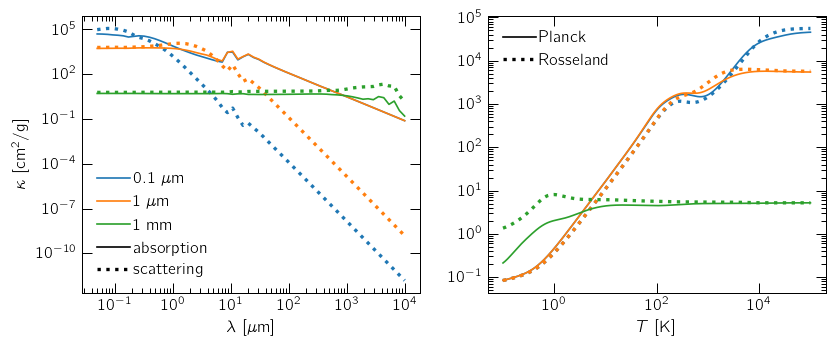

In [4]:
# check the opacities

fig, ax = plt.subplots(ncols=2, dpi=120, figsize=(8,3))

ax[0].plot(wl.to('um'), Dust01um.kabs_wl.to('cm2/g'), c='C0', label=r'0.1 $\mu$m')
ax[0].plot(wl.to('um'), Dust01um.ksca_wl.to('cm2/g'), c='C0', ls=':', lw=2)
ax[0].plot(wl.to('um'), Dust1um.kabs_wl.to('cm2/g'), c='C1', label=r'1 $\mu$m')
ax[0].plot(wl.to('um'), Dust1um.ksca_wl.to('cm2/g'), c='C1', ls=':', lw=2)
ax[0].plot(wl.to('um'), Dust1mm.kabs_wl.to('cm2/g'), c='C2', label='1 mm')
ax[0].plot(wl.to('um'), Dust1mm.ksca_wl.to('cm2/g'), c='C2', ls=':', lw=2)

ax[0].plot(np.nan, np.nan, c='k', ls='-', label='absorption')
ax[0].plot(np.nan, np.nan, c='k', ls=':', lw=2, label='scattering')

ax[1].plot(np.nan, np.nan, c='k', ls='-', label='Planck')
ax[1].plot(np.nan, np.nan, c='k', ls=':', lw=2, label='Rosseland')

T_opac = Dust01um.T_opac
# since kappa expects the fluid as an argument (but only uses fluid.tmp), make a dummy class that just contains tmp
class Foo: pass
foo = Foo(); foo.tmp = T_opac
ax[1].plot(T_opac, Dust01um.get_kappaP(foo), c='C0', ls='-', lw=1)
ax[1].plot(T_opac, Dust01um.get_kappaR(foo), c='C0', ls=':', lw=2)
ax[1].plot(T_opac, Dust1um.get_kappaP(foo), c='C1', ls='-', lw=1)
ax[1].plot(T_opac, Dust1um.get_kappaR(foo), c='C1', ls=':', lw=2)
ax[1].plot(T_opac, Dust1mm.get_kappaP(foo), c='C2', ls='-', lw=1)
ax[1].plot(T_opac, Dust1mm.get_kappaR(foo), c='C2', ls=':', lw=2)

for axis in ax: axis.legend()
for axis in ax: axis.loglog()
ax[0].set_xlabel(r'$\lambda$ [$\mu$m]')
ax[1].set_xlabel(r'$T$ [K]')
ax[0].set_ylabel(r'$\kappa$ [cm${}^2$/g]')
plt.show()

In [5]:
# run the model
for _ in range(10): Disk.advance(dt=1e10 * u.yr)

RadiativeEnvironment 'disk': Converged in 4 iterations.
RadiativeEnvironment 'disk': Converged in 7 iterations.
RadiativeEnvironment 'disk': Converged in 7 iterations.
RadiativeEnvironment 'disk': Converged in 7 iterations.
RadiativeEnvironment 'disk': Converged in 7 iterations.
RadiativeEnvironment 'disk': Converged in 6 iterations.
RadiativeEnvironment 'disk': Converged in 6 iterations.
RadiativeEnvironment 'disk': Converged in 6 iterations.
RadiativeEnvironment 'disk': Converged in 6 iterations.
RadiativeEnvironment 'disk': Converged in 5 iterations.


In [6]:
r = grid.x1[grid.act1].to_value('au')
theta = grid.x2[grid.act2]
phi = grid.x3[grid.act3]
mid = grid.mid

def fmt(qty3D): return 1 * qty3D[grid.active][0] # take the 0th (only) element in φ

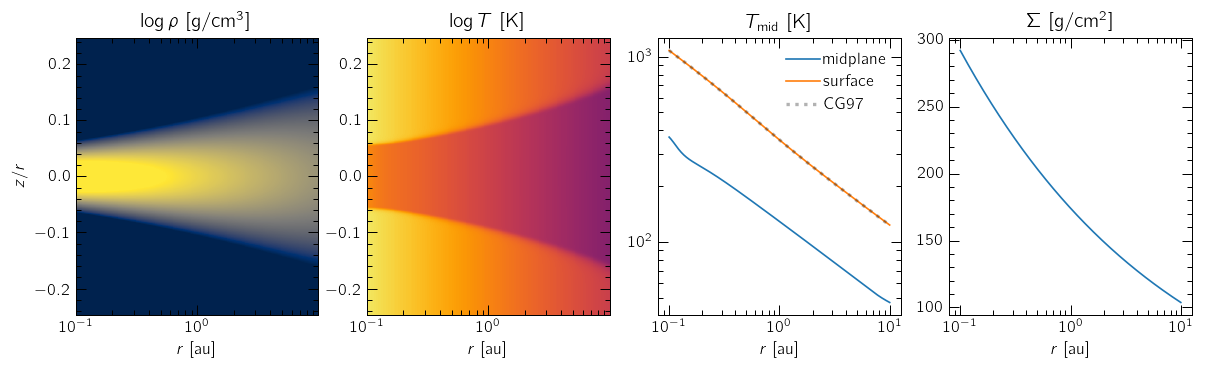

In [7]:
fig, ax = plt.subplots(ncols=4, figsize=(12, 3), dpi=120)
ax[0].pcolormesh(r, np.cos(theta), np.log10(fmt(Disk.rho).to_value('g/cm3')), cmap=plt.cm.cividis, vmin=-14, vmax=-9)
ax[0].pcolormesh(r, -np.cos(theta), np.log10(fmt(Disk.rho).to_value('g/cm3')), cmap=plt.cm.cividis, vmin=-14, vmax=-9)
ax[1].pcolormesh(r, np.cos(theta), np.log10(fmt(Disk.tmp).to_value('K')), cmap=plt.cm.inferno, vmin=0.8, vmax=3.2)
ax[1].pcolormesh(r, -np.cos(theta), np.log10(fmt(Disk.tmp).to_value('K')), cmap=plt.cm.inferno, vmin=0.8, vmax=3.2)
ax[2].plot(r, fmt(Disk.tmp).to_value('K')[mid], label='midplane')
ax[2].plot(r, fmt(Disk.tmp).to_value('K')[0], label='surface') # surface
ax[3].plot(r, (fmt(Disk.rho * grid.dz)).sum(0).to_value('g/cm2')) # surface density

for axis in ax: axis.set_xscale('log')
ax[2].set_yscale('log')

kappaStar, kappaDisk = 1 * Gas.kappaPstar, Gas.kappaP * fmt(np.ones(grid.shape))
for d2g, f in zip(d2gs, Dusts):
    kappaStar += d2g * f.kappaPstar
    kappaDisk += d2g * fmt(f.kappaP)
opac_factor = (kappaStar/kappaDisk[0]) ** 0.25
TCC97 = (star.T * np.sqrt(0.5*star.R/grid.x1[grid.act1])).to_value('K') * opac_factor
ax[2].plot(r, TCC97, ls=':', c='k', alpha=0.3, lw=2, label='CG97')

ax[2].legend()
# ax[2].plot(r, 132 * r ** -0.45)
for axis in ax: axis.set_xlabel(r'$r$ [au]')
ax[0].set_ylabel(r'$z/r$')
ax[0].set_title(r'$\log\rho$ [g/cm${}^3$]')
ax[1].set_title(r'$\log T$ [K]')
ax[2].set_title(r'$T_\mathrm{mid}$ [K]')
ax[3].set_title(r'$\Sigma$ [g/cm${}^2$]')

plt.show()

In [8]:
# now compute the density profile at this steady state
Disk.enforce_hydrostatic_equilibrium()

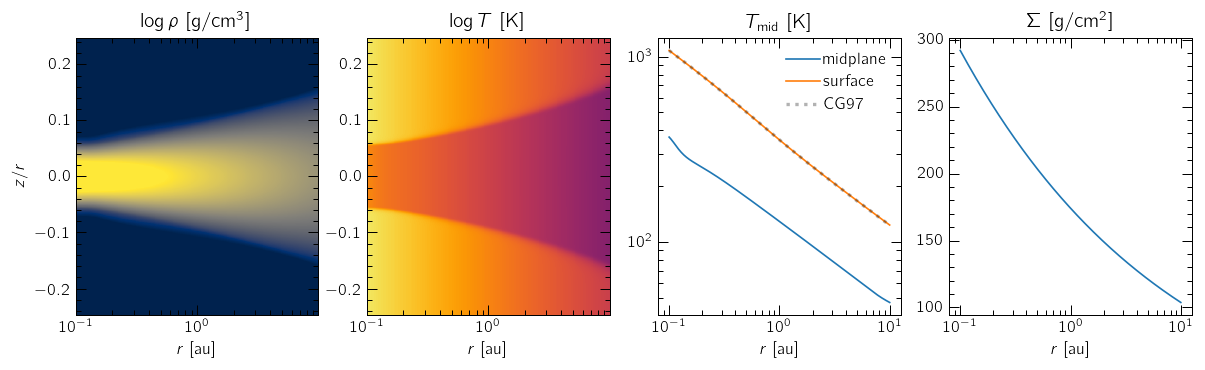

In [9]:
# and check the output
fig, ax = plt.subplots(ncols=4, figsize=(12, 3), dpi=120)
ax[0].pcolormesh(r, np.cos(theta), np.log10(fmt(Disk.rho).to_value('g/cm3')), cmap=plt.cm.cividis, vmin=-14, vmax=-9)
ax[0].pcolormesh(r, -np.cos(theta), np.log10(fmt(Disk.rho).to_value('g/cm3')), cmap=plt.cm.cividis, vmin=-14, vmax=-9)
ax[1].pcolormesh(r, np.cos(theta), np.log10(fmt(Disk.tmp).to_value('K')), cmap=plt.cm.inferno, vmin=0.8, vmax=3.2)
ax[1].pcolormesh(r, -np.cos(theta), np.log10(fmt(Disk.tmp).to_value('K')), cmap=plt.cm.inferno, vmin=0.8, vmax=3.2)
ax[2].plot(r, fmt(Disk.tmp).to_value('K')[mid], label='midplane')
ax[2].plot(r, fmt(Disk.tmp).to_value('K')[0], label='surface') # surface
ax[3].plot(r, (fmt(Disk.rho * grid.dz)).sum(0).to_value('g/cm2')) # surface density

for axis in ax: axis.set_xscale('log')
ax[2].set_yscale('log')

kappaStar, kappaDisk = 1 * Gas.kappaPstar, Gas.kappaP * fmt(np.ones(grid.shape))
for d2g, f in zip(d2gs, Dusts):
    kappaStar += d2g * f.kappaPstar
    kappaDisk += d2g * fmt(f.kappaP)
opac_factor = (kappaStar/kappaDisk[0]) ** 0.25
TCC97 = (star.T * np.sqrt(0.5*star.R/grid.x1[grid.act1])).to_value('K') * opac_factor
ax[2].plot(r, TCC97, ls=':', c='k', alpha=0.3, lw=2, label='CG97')

ax[2].legend()

for axis in ax: axis.set_xlabel(r'$r$ [au]')
ax[0].set_ylabel(r'$z/r$')
ax[0].set_title(r'$\log\rho$ [g/cm${}^3$]')
ax[1].set_title(r'$\log T$ [K]')
ax[2].set_title(r'$T_\mathrm{mid}$ [K]')
ax[3].set_title(r'$\Sigma$ [g/cm${}^2$]')

plt.show()

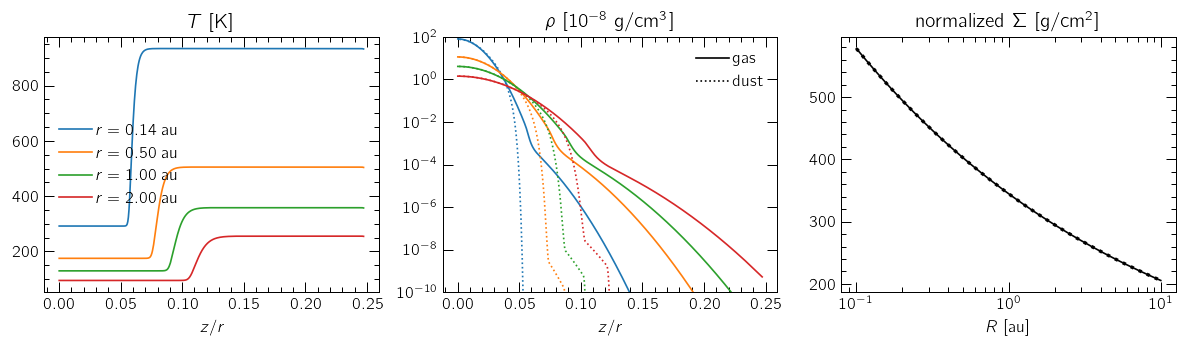

In [10]:
# check vertical structure
fig, ax = plt.subplots(ncols=3, figsize=(10,3), dpi=120)

g = grid
uden = 1e-10 * u.g / u.cm**3

for idx, r_target in enumerate([0.14, 0.5, 1, 2]):
    c = f'C{idx}'
    ridx = np.argmin(np.abs(r-r_target))
    ax[0].plot(np.cos(theta), fmt(Gas.tmp)[:, ridx].to_value('K'), c=c, label=r'$r=%.2f$ au'%r_target)
    ax[1].plot(np.cos(theta), fmt(Gas.rho)[:, ridx].to_value(uden), c=c)
    ax[1].plot(np.cos(theta), 1/d2gs[-1] * fmt(Dust.rho)[:, ridx].to_value(uden), c=c, ls=':')

ax[1].plot(np.nan, np.nan, ls='-', c='k', label='gas')
ax[1].plot(np.nan, np.nan, ls=':', c='k', label='dust')

ax[2].plot(r, fld.tools.get_surface_density(g, Gas.rho[g.active])[0].to_value('g/cm2'), c='k', ls='-')
ax[2].plot(r, fld.tools.get_surface_density(g, 1/d2gs[-1] * Dust.rho[g.active])[0].to_value('g/cm2'), c='k', ls=':', lw=2)

ax[0].legend()
ax[1].legend()

ax[1].set_yscale('log')
ax[1].set_ylim(1e-10, 100)
ax[2].set_xscale('log')

ax[0].set_xlabel(r'$z/r$')
ax[1].set_xlabel(r'$z/r$')
ax[2].set_xlabel(r'$R$ [au]')

ax[0].set_title(r'$T$ [K]')
ax[1].set_title(r'$\rho$ [$10^{-8}$ g/cm${}^3$]')
ax[2].set_title(r'normalized $\Sigma$ [g/cm${}^2$]')

fig.tight_layout()

plt.show()

In [11]:
# run the model again, alternating between temperature and density updates
Disk.verbose = False
for i in range(10):
    for _ in range(5): Disk.advance(dt=1e10 * u.yr)
    Disk.enforce_hydrostatic_equilibrium()
    print(f'finished supercycle {i}')

finished supercycle 0
finished supercycle 1
finished supercycle 2
finished supercycle 3
finished supercycle 4
finished supercycle 5
finished supercycle 6
finished supercycle 7
finished supercycle 8
finished supercycle 9


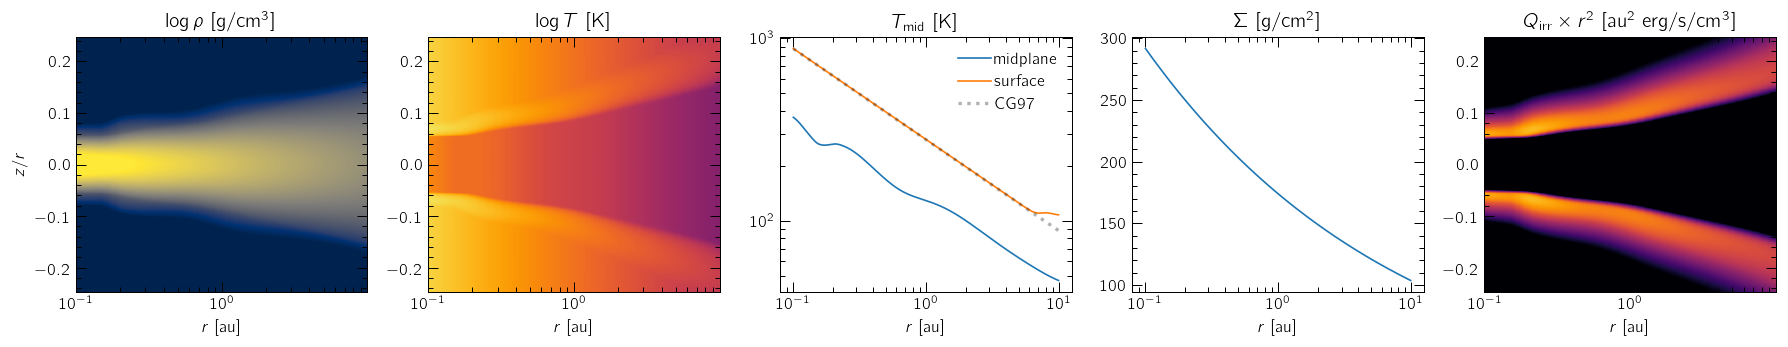

In [12]:
# and check the output again
fig, ax = plt.subplots(ncols=5, figsize=(15, 3), dpi=120)
ax[0].pcolormesh(r, np.cos(theta), np.log10(fmt(Disk.rho).to_value('g/cm3')), cmap=plt.cm.cividis, vmin=-14.5, vmax=-8.5)
ax[0].pcolormesh(r, -np.cos(theta), np.log10(fmt(Disk.rho).to_value('g/cm3')), cmap=plt.cm.cividis, vmin=-14.5, vmax=-8.5)
ax[1].pcolormesh(r, np.cos(theta), np.log10(fmt(Disk.tmp).to_value('K')), cmap=plt.cm.inferno, vmin=0.8, vmax=3.2)
ax[1].pcolormesh(r, -np.cos(theta), np.log10(fmt(Disk.tmp).to_value('K')), cmap=plt.cm.inferno, vmin=0.8, vmax=3.2)
ax[1].pcolormesh(r, -np.cos(theta), np.log10(fmt(Disk.tmp).to_value('K')), cmap=plt.cm.inferno, vmin=0.8, vmax=3.2)
ax[4].pcolormesh(r, np.cos(theta), np.log10(fmt(Disk.Qirr).to_value('erg/s/cm3')*r**2+1e-100), cmap=plt.cm.inferno, vmin=-12, vmax=-5)
ax[4].pcolormesh(r, -np.cos(theta), np.log10(fmt(Disk.Qirr).to_value('erg/s/cm3')*r**2+1e-100), cmap=plt.cm.inferno, vmin=-12, vmax=-5)
ax[2].plot(r, fmt(Disk.tmp).to_value('K')[mid], label='midplane')
ax[2].plot(r, fmt(Disk.tmp).to_value('K')[0], label='surface') # surface
ax[3].plot(r, (fmt(Disk.rho * grid.dz)).sum(0).to_value('g/cm2')) # surface density

for axis in ax: axis.set_xscale('log')
ax[2].set_yscale('log')

# there's only gas at the optically thin layers
opac_factor = (Gas.kappaPstar/Gas.kappaP) ** 0.25
TCC97 = (star.T * np.sqrt(0.5*star.R/grid.x1[grid.act1])).to_value('K') * opac_factor
ax[2].plot(r, TCC97, ls=':', c='k', alpha=0.3, lw=2, label='CG97')

ax[2].legend()

for axis in ax: axis.set_xlabel(r'$r$ [au]')
ax[0].set_ylabel(r'$z/r$')
ax[0].set_title(r'$\log\rho$ [g/cm${}^3$]')
ax[1].set_title(r'$\log T$ [K]')
ax[2].set_title(r'$T_\mathrm{mid}$ [K]')
ax[3].set_title(r'$\Sigma$ [g/cm${}^2$]')
ax[4].set_title(r'$Q_\mathrm{irr}\times r^2$ [au${}^2$ erg/s/cm${}^3$]')

fig.tight_layout()
plt.show()

In [13]:
# the deviation from the expected power law in the optically thin limit is simply
# due to the fact that the disk extends rather close to the top vertical boundary,
# which messes a bit with the transition between disk and atmosphere. You can fix
# this by extending the domain further up in the polar direction.